In [ ]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
rain_file_path = '../data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "../data/test.csv"
test_data = pd.read_csv(test_file_path)
test_data_full = pd.read_csv(test_file_path)

In [ ]:
rain_data.shape

(2190, 13)

In [ ]:
rain_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
rain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [ ]:
rain_data.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [ ]:
test_data.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

In [ ]:
test_data.loc[test_data.winddirection.isnull()]

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
517,2707,153,1007.8,32.9,30.6,28.9,22.0,65.0,75.0,8.2,NaN,17.2


In [ ]:
test_data["winddirection"][510:525]

510    220.0
511    100.0
512    220.0
513    230.0
514     10.0
515    230.0
516    100.0
517      NaN
518    220.0
519    220.0
520     50.0
521    220.0
522    220.0
523    220.0
524    230.0
Name: winddirection, dtype: float64

In [ ]:
test_data.fillna(value=160, inplace=True)

In [ ]:
test_data["winddirection"][510:525]

510    220.0
511    100.0
512    220.0
513    230.0
514     10.0
515    230.0
516    100.0
517    160.0
518    220.0
519    220.0
520     50.0
521    220.0
522    220.0
523    220.0
524    230.0
Name: winddirection, dtype: float64

In [ ]:
rain_data.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [ ]:
rain_data.drop(['id', 'day'], axis=1, inplace=True)
test_data.drop(['id', 'day'], axis=1, inplace=True)

In [ ]:
test_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [ ]:
rain_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data['rainfall']
X_test = test_data

In [ ]:
cols = X.columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

scaled_X = ms.fit_transform(X)
scaled_X_test = ms.fit_transform(X_test)

scaled_X = pd.DataFrame(scaled_X, columns=[cols])
scaled_X_test = pd.DataFrame(scaled_X_test, columns=[cols])

In [ ]:
scaled_X_test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,0.605590,0.355634,0.382239,0.341365,0.558052,0.966102,0.99,0.000000,0.137931,0.360000
1,0.512422,0.355634,0.409266,0.465863,0.565543,0.983051,0.99,0.000000,0.137931,0.560000
2,0.742236,0.133803,0.173745,0.208835,0.333333,0.796610,0.96,0.000000,0.103448,0.225455
3,0.711180,0.464789,0.440154,0.441767,0.355805,0.610169,0.45,0.601695,0.034483,0.838182
4,0.689441,0.306338,0.305019,0.088353,0.161049,0.491525,0.49,0.779661,0.034483,0.270909


In [ ]:
scaled_X.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,0.516854,0.421875,0.547718,0.616279,0.729630,0.813559,0.877551,0.090909,0.172414,0.232305
1,0.575843,0.226562,0.394191,0.457364,0.581481,0.949153,0.908163,0.000000,0.137931,0.317604
2,0.705056,0.351562,0.360996,0.410853,0.355556,0.610169,0.459184,0.685950,0.206897,0.248639
3,0.404494,0.300781,0.431535,0.500000,0.633333,0.949153,0.948980,0.000000,0.172414,0.566243
4,0.640449,0.425781,0.456432,0.434109,0.366667,0.220339,0.438776,0.297521,0.103448,0.370236


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0)

kmeans.fit(scaled_X)

KMeans(n_clusters=2, random_state=0)

In [ ]:
kmeans.inertia_

568.418044506102

In [ ]:
kmeans.cluster_centers_

array([[0.30577949, 0.79126968, 0.85217971, 0.85222186, 0.90813772,
        0.71839411, 0.70866375, 0.42902627, 0.48748764, 0.26070698],
       [0.53835427, 0.41786543, 0.4838436 , 0.52259733, 0.59746053,
        0.74298671, 0.80580065, 0.16264093, 0.13019609, 0.383614  ]])

In [ ]:
labels = kmeans.labels_

# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

Result: 1107 out of 2190 samples were correctly labeled.


In [ ]:
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Accuracy score: 0.51


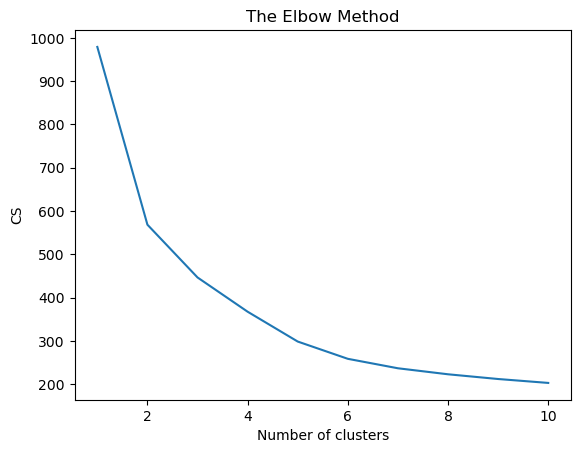

In [ ]:
from sklearn.cluster import KMeans
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(scaled_X)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)

kmeans.fit(scaled_X)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1107 out of 2190 samples were correctly labeled.
Accuracy score: 0.51


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)

kmeans.fit(scaled_X)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 468 out of 2190 samples were correctly labeled.
Accuracy score: 0.21


In [ ]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=0)

kmeans.fit(scaled_X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 829 out of 2190 samples were correctly labeled.
Accuracy score: 0.38


In [ ]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=0)

kmeans.fit(scaled_X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 452 out of 2190 samples were correctly labeled.
Accuracy score: 0.21


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0)
X["Cluster"] = kmeans.fit_predict(scaled_X)
X_test["Cluster"] = kmeans.fit_predict(scaled_X_test)

In [ ]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,2
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2
...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0


In [ ]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,3
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,3
...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [ ]:
features = X.columns

In [ ]:
features

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'Cluster'],
      dtype='object')

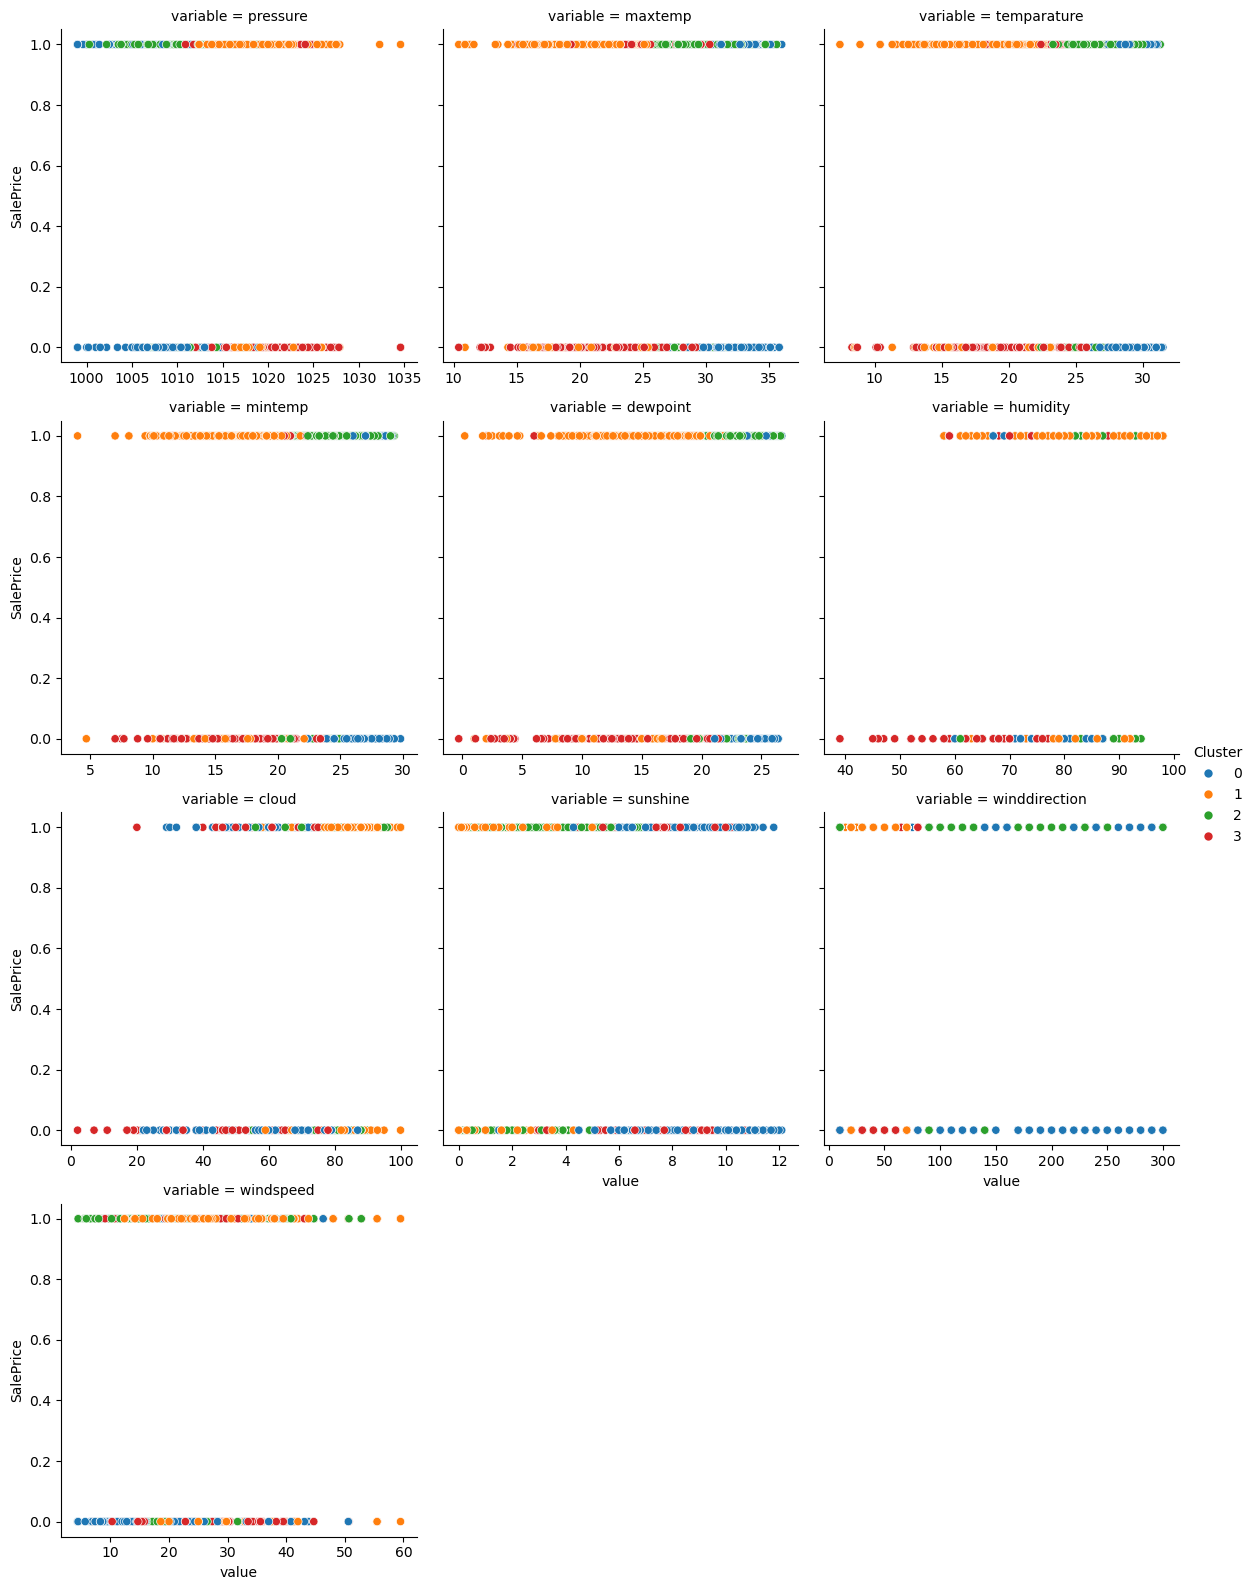

In [ ]:
Xy = X.copy()
Xy["Cluster"] = Xy.Cluster.astype("category")
Xy["SalePrice"] = y
sns.relplot(
    x="value", y="SalePrice", hue="Cluster", col="variable",
    height=4, aspect=1, facet_kws={'sharex': False}, col_wrap=3,
    data=Xy.melt(
        value_vars=features, id_vars=["SalePrice", "Cluster"],
    ),
);


In [ ]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,2
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2
...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0


In [ ]:
# YOUR CODE HERE: Create the cluster-distance features using `fit_transform`
X_cd = kmeans.fit_transform(scaled_X)
X_cd_test = kmeans.fit_transform(scaled_X_test)


# Label features and join to dataset
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_cd_test = pd.DataFrame(X_cd_test, columns=[f"Centroid_{i}" for i in range(X_cd_test.shape[1])])
X = X.join(X_cd)
X_test = X_test.join(X_cd_test)

In [ ]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,Centroid_2,Centroid_3
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0,0.284295,1.431103,0.981262,0.946067
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0,0.302797,1.387208,0.993150,0.887700
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0,0.604978,1.735045,1.113088,1.326723
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,2,0.885979,1.336926,0.614798,1.247250
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2,1.079471,1.571977,0.720873,1.535208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0,0.277465,1.422136,0.959197,0.929494
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0,0.306436,1.094434,0.672679,0.677923
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0,0.218582,1.290032,0.901257,0.783173
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0,0.399881,1.198609,0.965878,0.663092


In [ ]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,Centroid_2,Centroid_3
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,1.057672,0.305786,0.563395,0.751680
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,1.383512,0.254803,0.909152,0.909701
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,3,1.202962,0.846165,1.175040,0.384857
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,1.322305,0.308694,0.828157,0.950679
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,3,1.285391,0.785811,1.136742,0.577185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,1.136603,0.368936,0.594682,0.880997
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,1.341769,0.279527,0.872226,0.906391
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,1.198389,0.449192,0.943647,0.538835
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,1.458782,0.313374,1.004010,0.923613


In [ ]:
cols_scaling = X.columns

In [ ]:
X.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
Cluster            int32
Centroid_0       float64
Centroid_1       float64
Centroid_2       float64
Centroid_3       float64
dtype: object

In [ ]:
from mlxtend.preprocessing import minmax_scaling

X_scaled = minmax_scaling(X, columns=cols_scaling)
X_test_scaled = minmax_scaling(X_test, columns=cols_scaling)
X_scaled

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,Centroid_2,Centroid_3
0,0.516854,0.421875,0.547718,0.616279,0.729630,0.813559,0.877551,0.090909,0.172414,0.232305,0.333333,0.484697,0.117091,0.228927,0.509410
1,0.575843,0.226562,0.394191,0.457364,0.581481,0.949153,0.908163,0.000000,0.137931,0.317604,0.333333,0.656834,0.084811,0.410653,0.636818
2,0.705056,0.351562,0.360996,0.410853,0.355556,0.610169,0.459184,0.685950,0.206897,0.248639,1.000000,0.561452,0.459238,0.550401,0.213651
3,0.404494,0.300781,0.431535,0.500000,0.633333,0.949153,0.948980,0.000000,0.172414,0.566243,0.333333,0.624499,0.118933,0.368083,0.669857
4,0.640449,0.425781,0.456432,0.434109,0.366667,0.220339,0.438776,0.297521,0.103448,0.370236,1.000000,0.604998,0.421025,0.530272,0.368720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,0.438202,0.500000,0.547718,0.585271,0.748148,0.983051,0.877551,0.008264,0.103448,0.321234,0.333333,0.526395,0.157075,0.245371,0.613675
2186,0.376404,0.265625,0.410788,0.476744,0.577778,0.881356,0.877551,0.000000,0.137931,0.560799,0.333333,0.634782,0.100465,0.391245,0.634149
2187,0.401685,0.335937,0.369295,0.399225,0.477778,0.677966,0.785714,0.413223,0.103448,0.517241,0.333333,0.559036,0.207891,0.428783,0.337799
2188,0.654494,0.234375,0.323651,0.379845,0.555556,0.898305,0.928571,0.008264,0.103448,0.246824,0.333333,0.696598,0.121896,0.460509,0.648035


In [ ]:
X_test_scaled

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,Centroid_2,Centroid_3
0,0.605590,0.355634,0.382239,0.341365,0.558052,0.966102,0.99,0.000000,0.137931,0.360000,0.000000,0.100230,0.718425,0.681993,0.470687
1,0.512422,0.355634,0.409266,0.465863,0.565543,0.983051,0.99,0.000000,0.137931,0.560000,0.000000,0.112216,0.693757,0.692056,0.436103
2,0.742236,0.133803,0.173745,0.208835,0.333333,0.796610,0.96,0.000000,0.103448,0.225455,0.000000,0.307981,0.889237,0.793586,0.696237
3,0.711180,0.464789,0.440154,0.441767,0.355805,0.610169,0.45,0.601695,0.034483,0.838182,0.666667,0.490024,0.665499,0.371774,0.649147
4,0.689441,0.306338,0.305019,0.088353,0.161049,0.491525,0.49,0.779661,0.034483,0.270909,0.666667,0.615376,0.797595,0.461568,0.819770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,0.645963,0.380282,0.451737,0.477912,0.513109,0.966102,0.95,0.000000,0.034483,0.541818,0.000000,0.095805,0.713386,0.663314,0.460867
726,0.363354,0.556338,0.471042,0.473896,0.599251,0.661017,0.80,0.135593,0.103448,0.376364,0.000000,0.114574,0.529222,0.420771,0.311803
727,0.704969,0.478873,0.486486,0.514056,0.580524,0.898305,0.96,0.000000,0.137931,0.316364,0.000000,0.057659,0.639146,0.614267,0.374167
728,0.447205,0.478873,0.544402,0.622490,0.741573,0.932203,0.93,0.000000,0.137931,0.636364,0.000000,0.175111,0.587767,0.668970,0.303016


In [ ]:
# Define the model. Set random_state to 1
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X_scaled, y)
#rf_preds = rf_model.predict(val_X)
score = cross_val_score(rf_model, X_scaled, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.86298994 0.90691577 0.91156101 0.86400268 0.85780033]


0.880653942797928

In [ ]:
xgb_model = XGBRegressor()
xgb_model.fit(X_scaled, y)
score = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.83710275 0.8574238  0.87225047 0.82373609 0.82118623]


0.8423398672889888

In [ ]:
# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y,
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)

In [ ]:
# Define the model. Set random_state to 1
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_valid)
score = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.89012725 0.83570632 0.79948598 0.87042301 0.86665715]


0.852479942981115

In [ ]:
rf_model.fit(X_scaled, y)
rf_test_preds = rf_model.predict(X_test)

In [ ]:
test_data_full["id"]

0      2190
1      2191
2      2192
3      2193
4      2194
       ... 
725    2915
726    2916
727    2917
728    2918
729    2919
Name: id, Length: 730, dtype: int64

In [ ]:
X_test["id"] = test_data_full["id"]


In [ ]:
X_test["rainfall"] = rf_test_preds

In [ ]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,Centroid_2,Centroid_3,id,rainfall
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0,0.284295,1.431103,0.981262,0.946067,2190,0.53
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0,0.302797,1.387208,0.993150,0.887700,2191,0.53
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0,0.604978,1.735045,1.113088,1.326723,2192,0.53
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,2,0.885979,1.336926,0.614798,1.247250,2193,0.50
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2,1.079471,1.571977,0.720873,1.535208,2194,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0,0.277465,1.422136,0.959197,0.929494,2915,0.53
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0,0.306436,1.094434,0.672679,0.677923,2916,0.49
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0,0.218582,1.290032,0.901257,0.783173,2917,0.50
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0,0.399881,1.198609,0.965878,0.663092,2918,0.53


In [ ]:
X_test.to_csv('submission.csv', columns=['id','rainfall'], index=False)

In [ ]:
X_test.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
Cluster            int32
Centroid_0       float64
Centroid_1       float64
Centroid_2       float64
Centroid_3       float64
id                 int64
rainfall         float64
dtype: object